## LOAD THE CLEANED DATASET

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
import pandas as pd
clinical = pd.read_csv("clinical_cleaned.csv")


In [58]:
clinical.shape


(60337, 6)

In [59]:
clinical.head()

,brief_summary,source_condition_query,conditions,minimum_age,maximum_age,clean_summary
0,Breast cancer patients often have perioperativ...,breast cancer,Breast Cancer,20 Years,65 Years,breast cancer patient often perioperative emot...
1,Many breast cancer patients experience psychol...,breast cancer,Breast Cancer,18 Years,NaN,many breast cancer patient experience psycholo...
2,"Based on an American study by Scherer et al., ...",breast cancer,Breast Neoplasm Female | Mammography Screening...,44 Years,49 Years,based american study scherer et al hypothesize...
3,Compare the effect of ropivacaine versus place...,breast cancer,Malignant Neoplasm of Breast,18 Years,85 Years,compare effect ropivacaine versus placebo pect...
4,Phase 1 dose escalation and expansion study of...,breast cancer,Advanced Solid Tumor | Unresectable Solid Tumo...,18 Years,NaN,phase dose escalation expansion study clsp fir...


In [60]:
print(clinical.columns)

Index(['brief_summary', 'source_condition_query', 'conditions', 'minimum_age',
       'maximum_age', 'clean_summary'],
      dtype='str')


## REMOVING YEARS IN AGE COLUMN

In [61]:
clinical["minimum_age"] = clinical["minimum_age"].str.replace(" Years", "", regex=False)
clinical["maximum_age"] = clinical["maximum_age"].str.replace(" Years", "", regex=False)

clinical["minimum_age"] = pd.to_numeric(clinical["minimum_age"], errors="coerce")
clinical["maximum_age"] = pd.to_numeric(clinical["maximum_age"], errors="coerce")

In [62]:
clinical.isnull().sum()

brief_summary                 0
source_condition_query        0
conditions                    1
minimum_age                3756
maximum_age               32075
clean_summary                 0
dtype: int64

In [63]:
clinical = clinical.rename(columns={"source_condition_query": "Disease"})

In [64]:
clinical.head()

,brief_summary,Disease,conditions,minimum_age,maximum_age,clean_summary
0,Breast cancer patients often have perioperativ...,breast cancer,Breast Cancer,20.0,65.0,breast cancer patient often perioperative emot...
1,Many breast cancer patients experience psychol...,breast cancer,Breast Cancer,18.0,NaN,many breast cancer patient experience psycholo...
2,"Based on an American study by Scherer et al., ...",breast cancer,Breast Neoplasm Female | Mammography Screening...,44.0,49.0,based american study scherer et al hypothesize...
3,Compare the effect of ropivacaine versus place...,breast cancer,Malignant Neoplasm of Breast,18.0,85.0,compare effect ropivacaine versus placebo pect...
4,Phase 1 dose escalation and expansion study of...,breast cancer,Advanced Solid Tumor | Unresectable Solid Tumo...,18.0,NaN,phase dose escalation expansion study clsp fir...


In [65]:
clinical = clinical[["Disease","conditions","minimum_age","maximum_age","brief_summary","clean_summary"]]

In [66]:
clinical.head()

,Disease,conditions,minimum_age,maximum_age,brief_summary,clean_summary
0,breast cancer,Breast Cancer,20.0,65.0,Breast cancer patients often have perioperativ...,breast cancer patient often perioperative emot...
1,breast cancer,Breast Cancer,18.0,NaN,Many breast cancer patients experience psychol...,many breast cancer patient experience psycholo...
2,breast cancer,Breast Neoplasm Female | Mammography Screening...,44.0,49.0,"Based on an American study by Scherer et al., ...",based american study scherer et al hypothesize...
3,breast cancer,Malignant Neoplasm of Breast,18.0,85.0,Compare the effect of ropivacaine versus place...,compare effect ropivacaine versus placebo pect...
4,breast cancer,Advanced Solid Tumor | Unresectable Solid Tumo...,18.0,NaN,Phase 1 dose escalation and expansion study of...,phase dose escalation expansion study clsp fir...


# EDA

## AGE ANALYSIS

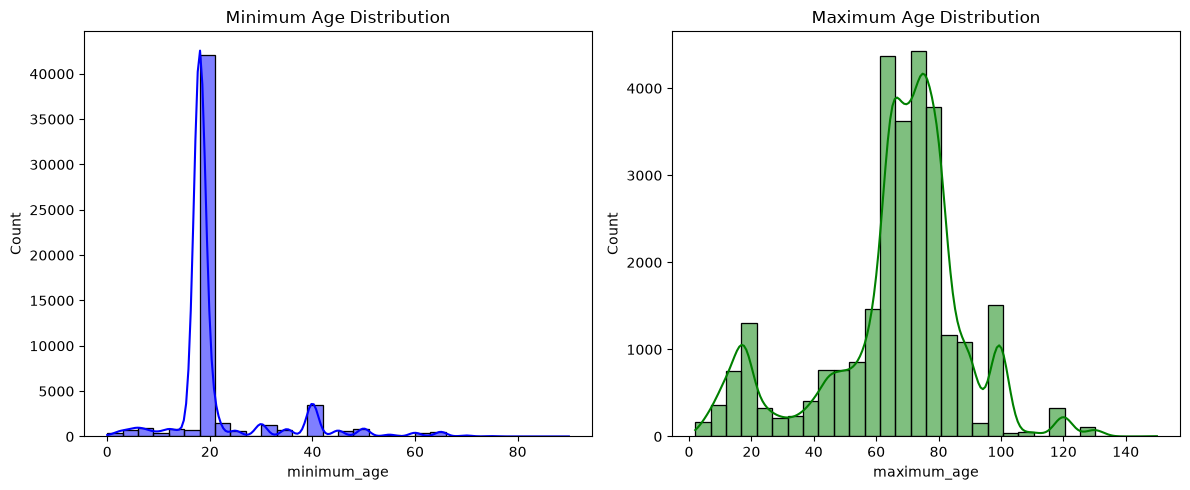

In [67]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(clinical['minimum_age'], bins=30, kde=True, color='blue')
plt.title("Minimum Age Distribution")

plt.subplot(1,2,2)
sns.histplot(clinical['maximum_age'], bins=30, kde=True, color='green')
plt.title("Maximum Age Distribution")

plt.tight_layout()
plt.show()


## DISEASE AND CONDITION ANALYSIS

C:\Users\nivit\AppData\Local\Temp\ipykernel_8972\2602184900.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_disease.index, x=top_disease.values, palette="viridis")


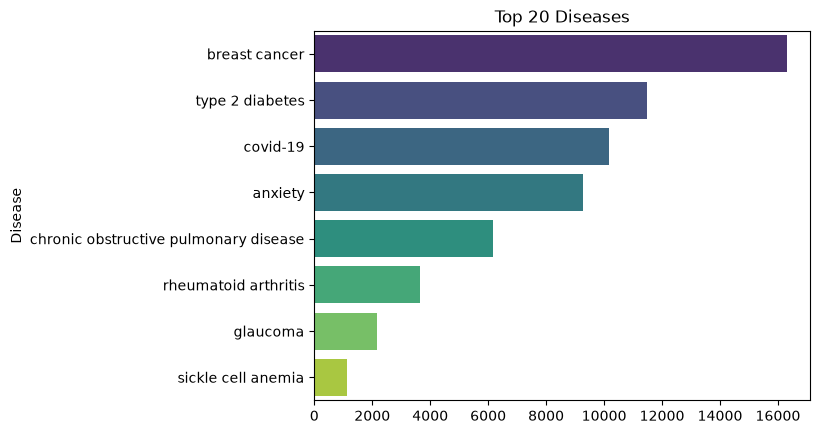

C:\Users\nivit\AppData\Local\Temp\ipykernel_8972\2602184900.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_conditions.index, x=top_conditions.values, palette="magma")


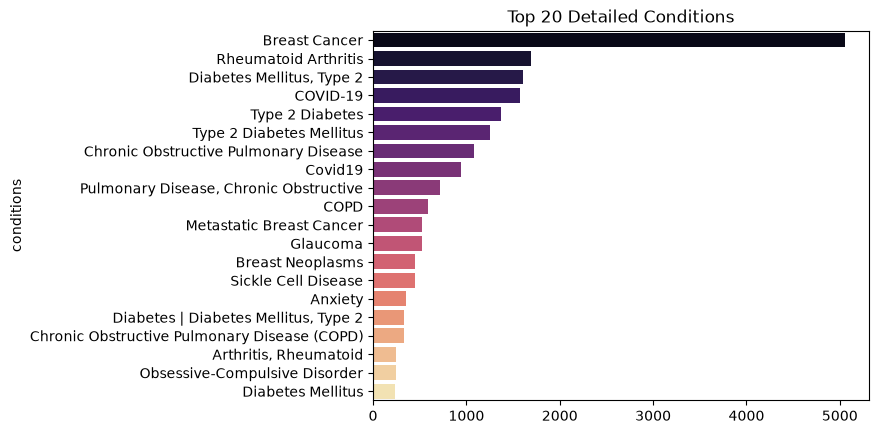

In [68]:
# Top diseases
top_disease = clinical['Disease'].value_counts().head(20)
sns.barplot(y=top_disease.index, x=top_disease.values, palette="viridis")
plt.title("Top 20 Diseases")
plt.show()

# Top detailed conditions
top_conditions = clinical['conditions'].value_counts().head(20)
sns.barplot(y=top_conditions.index, x=top_conditions.values, palette="magma")
plt.title("Top 20 Detailed Conditions")
plt.show()


## TEXT INSIGHTS

C:\Users\nivit\AppData\Local\Temp\ipykernel_8972\2602184900.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_disease.index, x=top_disease.values, palette="viridis")


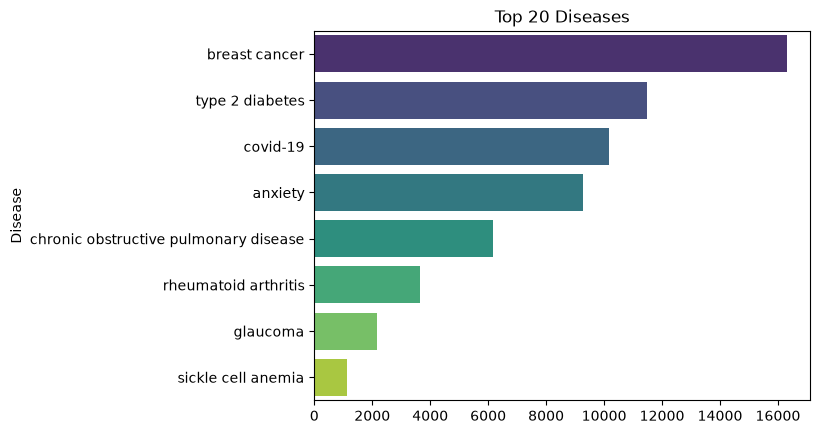

C:\Users\nivit\AppData\Local\Temp\ipykernel_8972\2602184900.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_conditions.index, x=top_conditions.values, palette="magma")


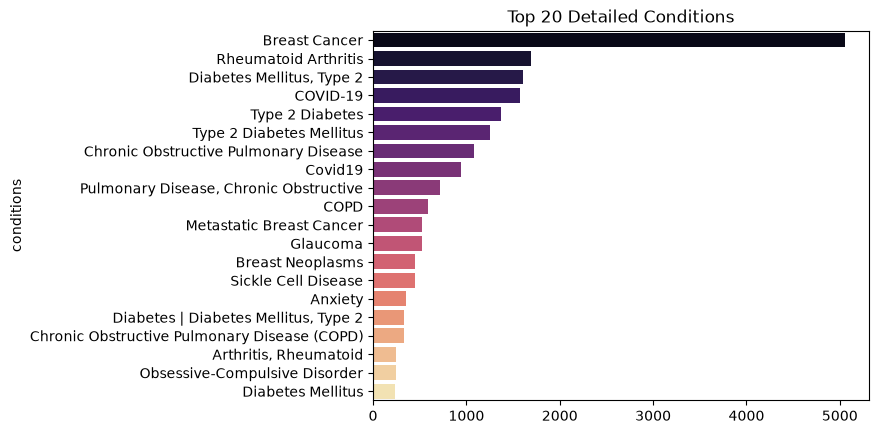

In [69]:
# Top diseases
top_disease = clinical['Disease'].value_counts().head(20)
sns.barplot(y=top_disease.index, x=top_disease.values, palette="viridis")
plt.title("Top 20 Diseases")
plt.show()

# Top detailed conditions
top_conditions = clinical['conditions'].value_counts().head(20)
sns.barplot(y=top_conditions.index, x=top_conditions.values, palette="magma")
plt.title("Top 20 Detailed Conditions")
plt.show()


## BIVARIANT ANALYSIS

C:\Users\nivit\AppData\Local\Temp\ipykernel_8972\2602184900.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_disease.index, x=top_disease.values, palette="viridis")


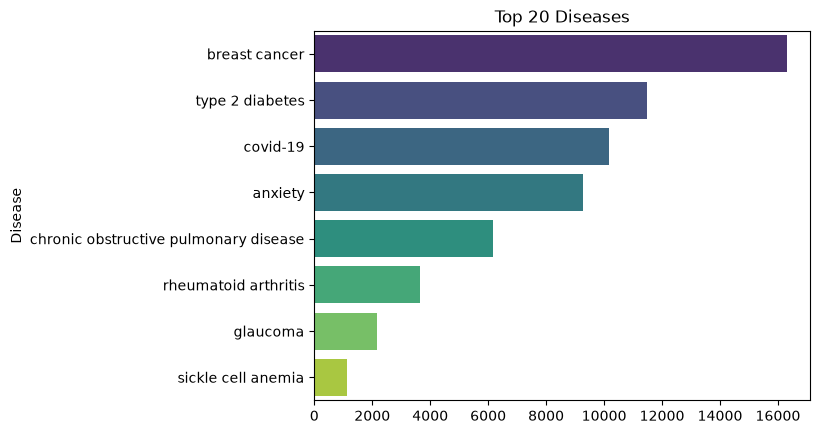

C:\Users\nivit\AppData\Local\Temp\ipykernel_8972\2602184900.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_conditions.index, x=top_conditions.values, palette="magma")


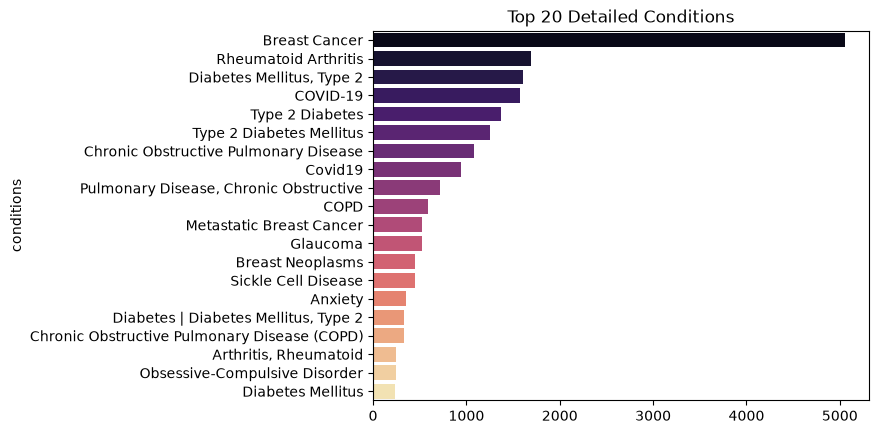

In [70]:
# Top diseases
top_disease = clinical['Disease'].value_counts().head(20)
sns.barplot(y=top_disease.index, x=top_disease.values, palette="viridis")
plt.title("Top 20 Diseases")
plt.show()

# Top detailed conditions
top_conditions = clinical['conditions'].value_counts().head(20)
sns.barplot(y=top_conditions.index, x=top_conditions.values, palette="magma")
plt.title("Top 20 Detailed Conditions")
plt.show()


## AGE VS DISEASE

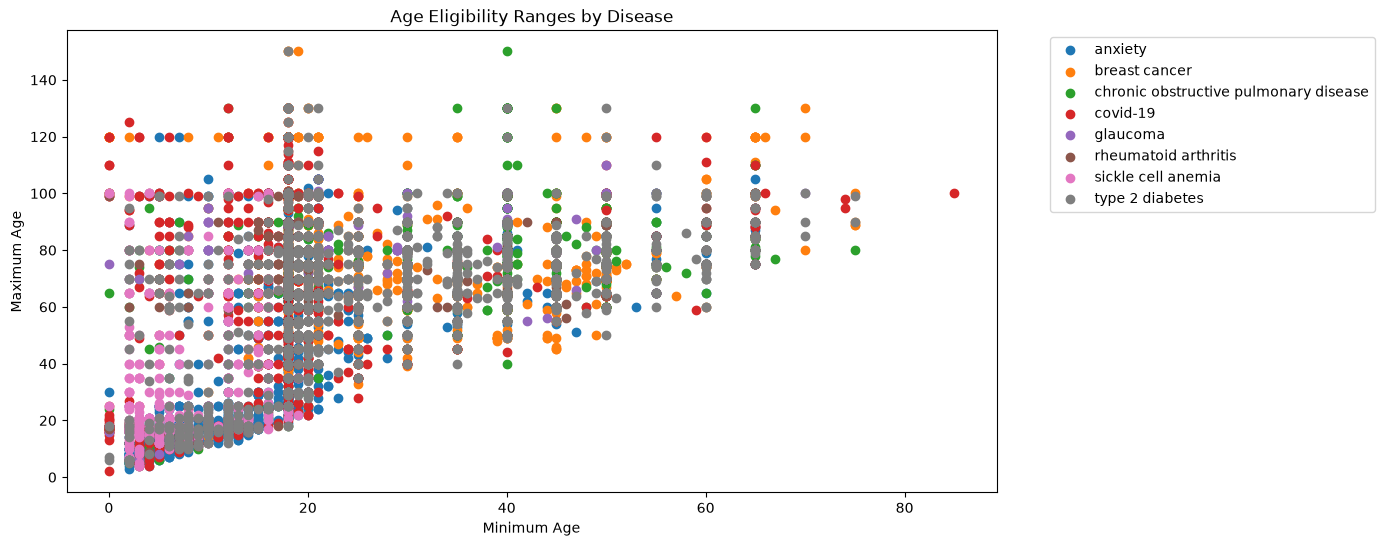

In [71]:
# Plot min vs max age ranges for each disease
plt.figure(figsize=(12,6))
for disease, group in clinical.groupby("Disease"):
    plt.scatter(group['minimum_age'], group['maximum_age'], label=disease)

plt.xlabel("Minimum Age")
plt.ylabel("Maximum Age")
plt.title("Age Eligibility Ranges by Disease")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


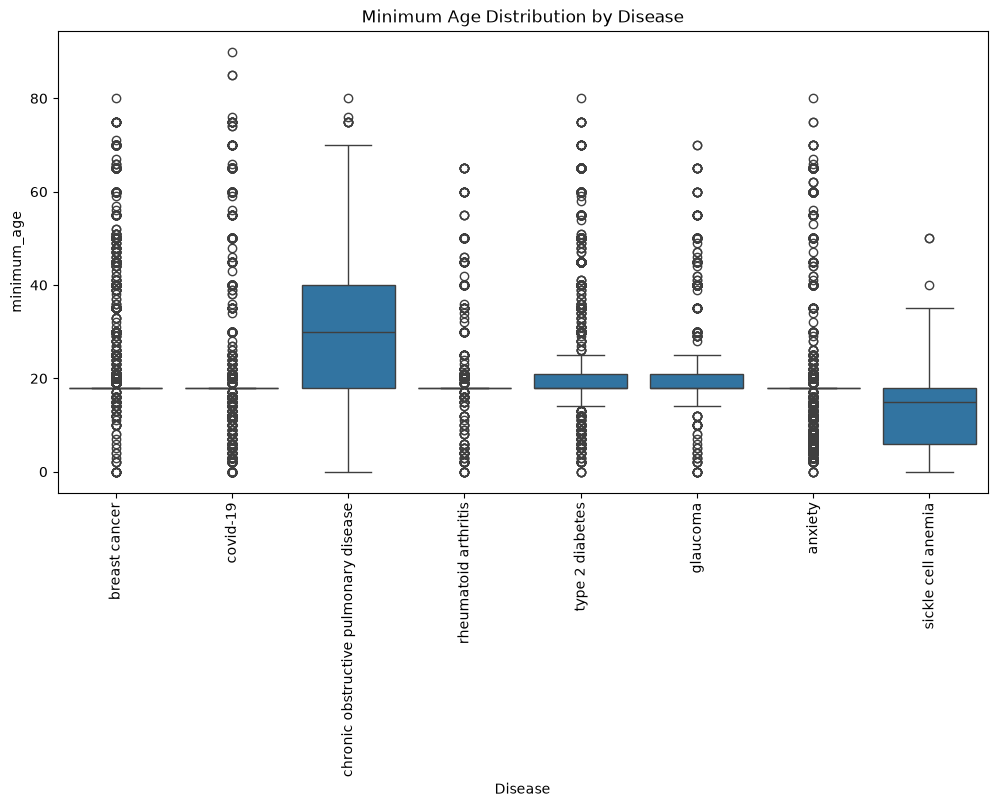

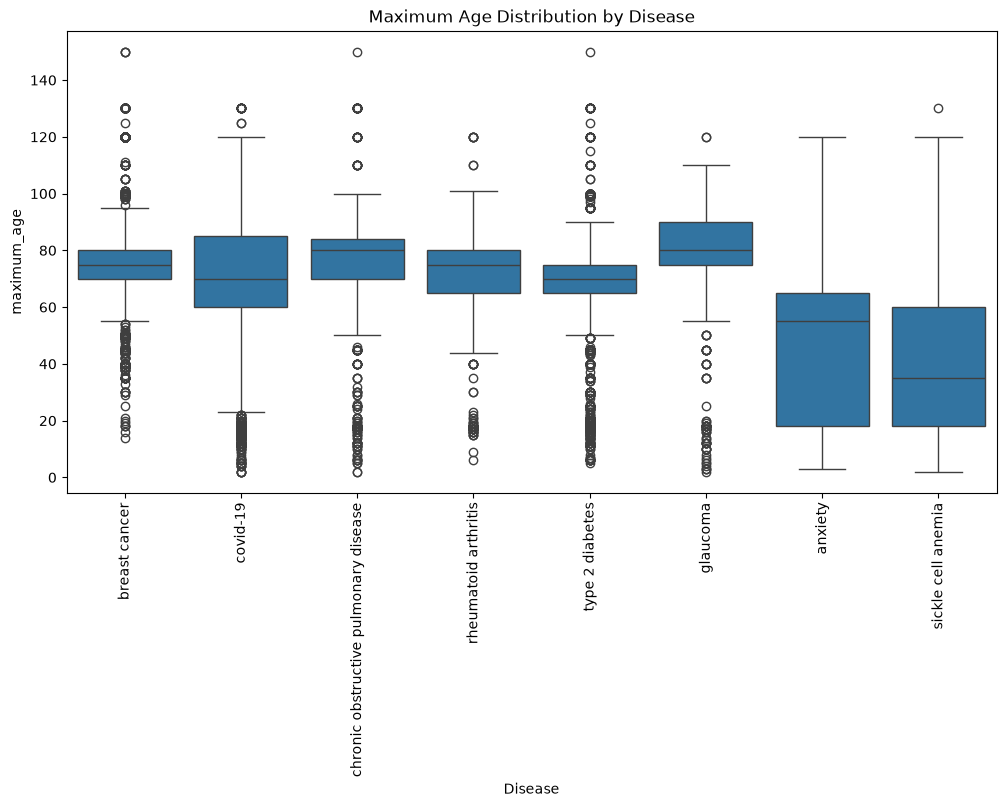

In [72]:
plt.figure(figsize=(12, 6))
sns.boxplot(x="Disease", y="minimum_age", data=clinical)
plt.xticks(rotation=90)
plt.title("Minimum Age Distribution by Disease")
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(x="Disease", y="maximum_age", data=clinical)
plt.xticks(rotation=90)
plt.title("Maximum Age Distribution by Disease")
plt.show()

In [73]:
# Create age bands
bins = [0, 18, 30, 50, 70, 100]
labels = ["0-17", "18-30", "31-50", "51-70", "71+"]

clinical["age_band"] = pd.cut(
    clinical["minimum_age"], bins=bins, labels=labels, right=True
)

In [74]:
# Count trials per disease per age band
age_group_counts = (
    clinical.groupby(["Disease", "age_band"]).size().reset_index(name="count")
)
print(age_group_counts.head(10))

         Disease age_band  count
0        anxiety     0-17   7768
1        anxiety    18-30    622
2        anxiety    31-50    196
3        anxiety    51-70    248
4        anxiety      71+      3
5  breast cancer     0-17  12615
6  breast cancer    18-30   1565
7  breast cancer    31-50    892
8  breast cancer    51-70    281
9  breast cancer      71+     14


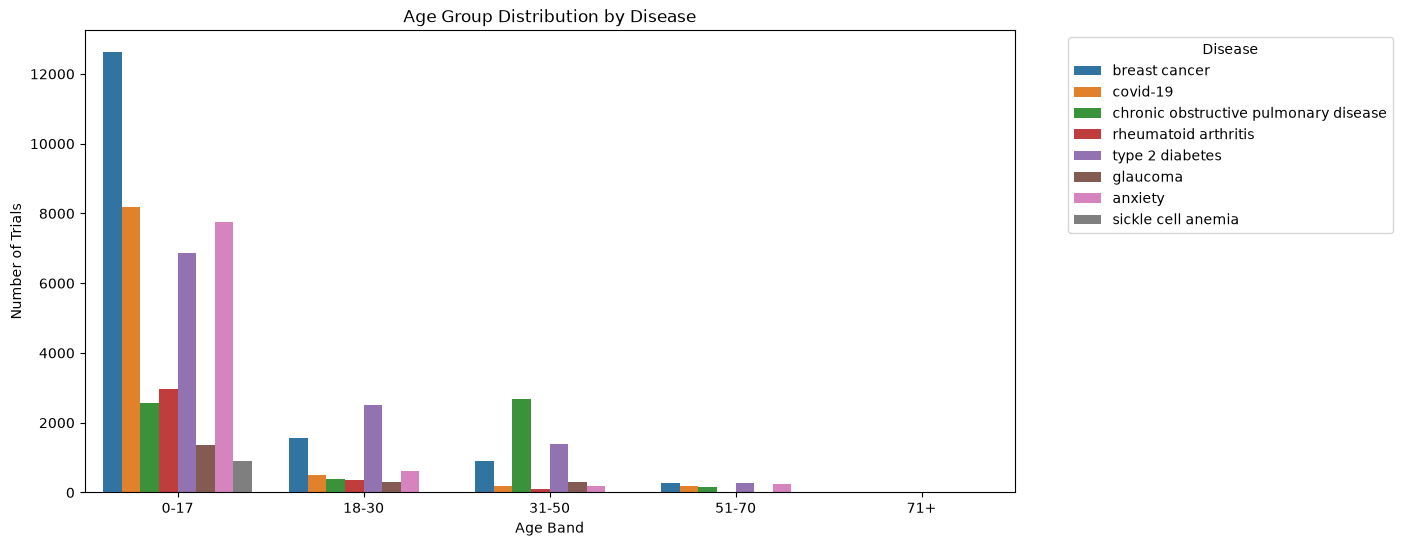

In [75]:
plt.figure(figsize=(12, 6))
sns.countplot(x="age_band", hue="Disease", data=clinical)
plt.title("Age Group Distribution by Disease")
plt.xlabel("Age Band")
plt.ylabel("Number of Trials")
plt.legend(title="Disease", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

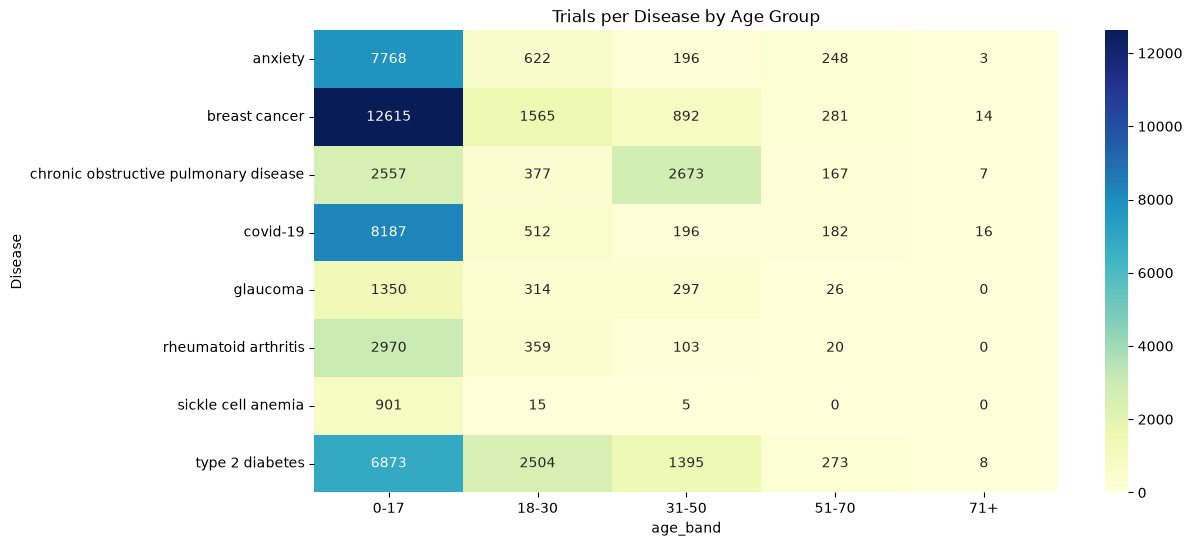

In [76]:
pivot = age_group_counts.pivot(
    index="Disease", columns="age_band", values="count"
).fillna(0)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt="g", cmap="YlGnBu")
plt.title("Trials per Disease by Age Group")
plt.show()

## DROPING AGE COLUMNS AND SAVING

In [77]:
clinical = clinical.drop(columns=["minimum_age", "maximum_age", "age_band"])
clinical.to_csv("clinical_day1.csv", index=False)

In [78]:
clinical.head()

,Disease,conditions,brief_summary,clean_summary
0,breast cancer,Breast Cancer,Breast cancer patients often have perioperativ...,breast cancer patient often perioperative emot...
1,breast cancer,Breast Cancer,Many breast cancer patients experience psychol...,many breast cancer patient experience psycholo...
2,breast cancer,Breast Neoplasm Female | Mammography Screening...,"Based on an American study by Scherer et al., ...",based american study scherer et al hypothesize...
3,breast cancer,Malignant Neoplasm of Breast,Compare the effect of ropivacaine versus place...,compare effect ropivacaine versus placebo pect...
4,breast cancer,Advanced Solid Tumor | Unresectable Solid Tumo...,Phase 1 dose escalation and expansion study of...,phase dose escalation expansion study clsp fir...
